In [32]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import spacy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
)
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.multiclass import OneVsRestClassifier

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RobotComp.ru\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
df = pd.read_csv("rusentiment_random_posts.csv")
df["text"] = df["text"].astype(str)

In [9]:
nlp = spacy.load("ru_core_news_sm")
stemmer = SnowballStemmer("russian")
stop_words = set(stopwords.words("russian"))

In [10]:
def lemmatize_text(text):

    text = text.lower()
    
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\[.*?\]", " ", text)
    text = re.sub(r"[^а-яa-z\s]", " ", text)
    
    doc = nlp(text)
    
    tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    
    return " ".join(tokens)

In [48]:
def stemming_text(text):
    # Нижний регистр
    text = text.lower()
    

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\[.*?\]", " ", text)
    text = re.sub(r"[^а-яa-z\s]", " ", text)
    
    tokens = text.split()
    
    tokens = [t for t in tokens if t not in stop_words]
    
    tokens = [stemmer.stem(t) for t in tokens]
    
    return " ".join(tokens)

In [12]:
df["clean_text"] = df["text"].apply(lemmatize_text)

In [15]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]
print("Размерность матрицы BoW:", X.shape)

Размерность матрицы BoW: (21268, 33012)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "Test set:", X_test.shape)

Train set: (17014, 33012) Test set: (4254, 33012)


In [40]:
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(
    max_iter=1000,
    solver="saga"
)
svc = LinearSVC()

ada = AdaBoostClassifier(estimator=logreg, n_estimators=10, random_state=42)

voting = VotingClassifier(
    estimators=[("knn", knn), ("logreg", logreg), ("svc", svc)],
    voting="hard"
)

In [41]:
models = {
    "KNN": knn,
    "LogisticRegression": logreg,
    "LinearSVC": svc,
    "AdaBoost_LogReg": ada,
    "HardVoting": voting
}

In [42]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average="weighted"),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "model": model
    }

In [43]:
for name, metrics in results.items():
    print(f"=== {name} ===")
    print("Accuracy :", metrics["accuracy"])
    print("F1       :", metrics["f1"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print()

=== KNN ===
Accuracy : 0.5126939351198871
F1       : 0.4558573148923609
Precision: 0.4834265197403521
Recall   : 0.5126939351198871

=== LogisticRegression ===
Accuracy : 0.6086036671368125
F1       : 0.5845649014433365
Precision: 0.6090371307921012
Recall   : 0.6086036671368125

=== LinearSVC ===
Accuracy : 0.5987306064880112
F1       : 0.5846516232154761
Precision: 0.5866303817804797
Recall   : 0.5987306064880112

=== AdaBoost_LogReg ===
Accuracy : 0.5324400564174894
F1       : 0.48679833539440837
Precision: 0.5251833498227904
Recall   : 0.5324400564174894

=== HardVoting ===
Accuracy : 0.6057827926657263
F1       : 0.5810913476481951
Precision: 0.604130864790676
Recall   : 0.6057827926657263



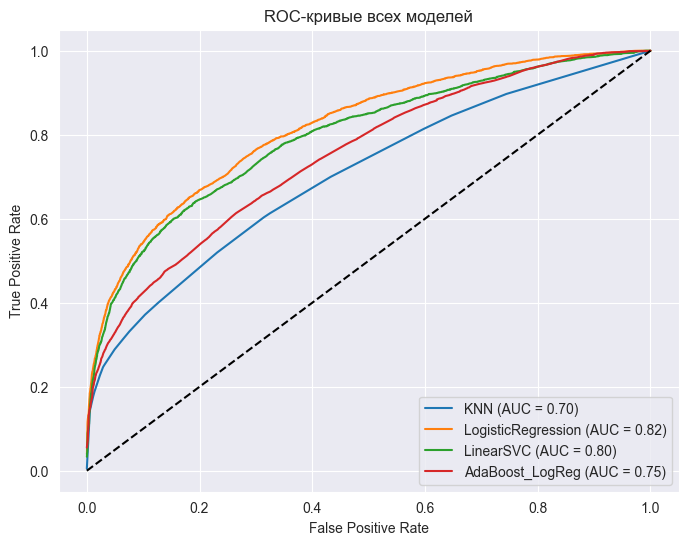

In [46]:
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

plt.figure(figsize=(8,6))

for name, metrics in results.items():
    model = metrics["model"]
    if name == "HardVoting":
        continue
    # Для KNN и LogisticRegression используем predict_proba
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:  # LinearSVC использует decision_function
        y_score = model.decision_function(X_test)
    
    # ROC для каждого класса
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_test_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Средняя ROC кривая
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(y_test_bin.shape[1])]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(y_test_bin.shape[1]):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= y_test_bin.shape[1]
    mean_auc = auc(all_fpr, mean_tpr)
    
    plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые всех моделей")
plt.legend(loc="lower right")
plt.show()

In [49]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)     
)
df["clean_text"] = df["text"].apply(stemming_text)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

print("Матрица TF-IDF:", X.shape)
print(df[["text", "clean_text", "label"]].head())

Матрица TF-IDF: (21268, 5000)
                                                text  \
0  А попа подозревала давно,что ты с кавказа..пер...   
1                    З прошедшим Днем Ангела))))))))   
2                 Два дня до отлёта с острова!!!!!!!   
3   Блин, почему эта жизнь столь не справедлива ((((   
4  где еще встречать свой день рождения как не на...   

                                    clean_text     label  
0  поп подозрева давн кавказ перестан обща тоб  negative  
1                         з прошедш днем ангел    speech  
2                            дня отл та остров      skip  
3             блин поч эт жизн стол справедлив  negative  
4               встреча сво ден рожден кладбищ      skip  


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "Test set:", X_test.shape)

Train set: (17014, 5000) Test set: (4254, 5000)


In [51]:
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(
    max_iter=1000,
    solver="saga"
)
svc = LinearSVC()

ada = AdaBoostClassifier(estimator=logreg, n_estimators=10, random_state=42)

voting = VotingClassifier(
    estimators=[("knn", knn), ("logreg", logreg), ("svc", svc)],
    voting="hard"
)

In [52]:
models = {
    "KNN": knn,
    "LogisticRegression": logreg,
    "LinearSVC": svc,
    "AdaBoost_LogReg": ada,
    "HardVoting": voting
}

In [53]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average="weighted"),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "model": model
    }

D:\My Code\R\R\task4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [54]:
for name, metrics in results.items():
    print(f"=== {name} ===")
    print("Accuracy :", metrics["accuracy"])
    print("F1       :", metrics["f1"])
    print("Precision:", metrics["precision"])
    print("Recall   :", metrics["recall"])
    print()

=== KNN ===
Accuracy : 0.4722614010343206
F1       : 0.46321173279907346
Precision: 0.4859282829959209
Recall   : 0.4722614010343206

=== LogisticRegression ===
Accuracy : 0.6118946873530795
F1       : 0.5819874082002693
Precision: 0.6152157700449372
Recall   : 0.6118946873530795

=== LinearSVC ===
Accuracy : 0.5966149506346967
F1       : 0.5827940398420488
Precision: 0.5836734304010311
Recall   : 0.5966149506346967

=== AdaBoost_LogReg ===
Accuracy : 0.4125528913963329
F1       : 0.26095924184759134
Precision: 0.2990126385462955
Recall   : 0.4125528913963329

=== HardVoting ===
Accuracy : 0.6081335213916315
F1       : 0.5844390357900364
Precision: 0.6056747596611625
Recall   : 0.6081335213916315



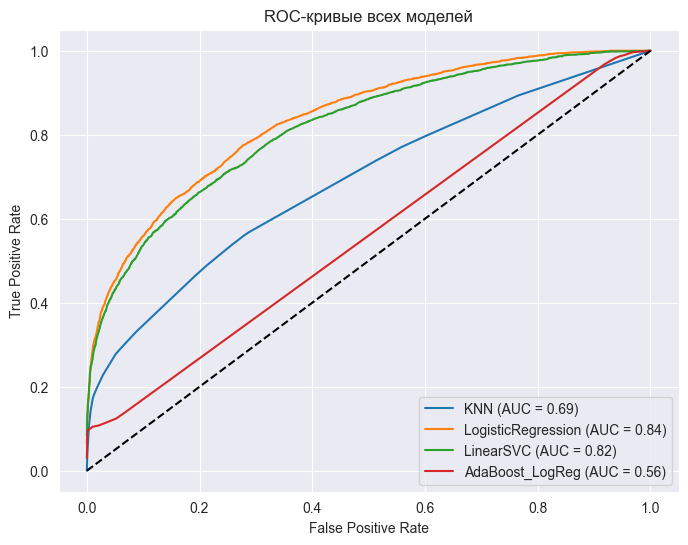

In [55]:
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

plt.figure(figsize=(8,6))

for name, metrics in results.items():
    model = metrics["model"]
    if name == "HardVoting":
        continue
    # Для KNN и LogisticRegression используем predict_proba
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:  # LinearSVC использует decision_function
        y_score = model.decision_function(X_test)
    
    # ROC для каждого класса
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_test_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Средняя ROC кривая
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(y_test_bin.shape[1])]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(y_test_bin.shape[1]):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= y_test_bin.shape[1]
    mean_auc = auc(all_fpr, mean_tpr)
    
    plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые всех моделей")
plt.legend(loc="lower right")
plt.show()